# Fingerprint class prediction ability

- we use Classyfire `Subclass` as labels to train a simple neural network on predicting those labels from fingerprints.
  

In [ ]:
import os
from pathlib import Path

import multiprocessing as mp
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

ROOT = Path(os.getcwd()).parents[0]
path_data = os.path.join(Path(ROOT), "data")

In [2]:
from chemap.fingerprint_statistics import unfolded_count_fingerprint_bit_statistics
from chemap import metrics
from chemap.fingerprint_computation import compute_fingerprints, FingerprintConfig
from chemap.fingerprint_conversions import fingerprints_to_csr

In [ ]:
# import fingerprint algorithms
from rdkit.Chem import rdFingerprintGenerator
from skfp.fingerprints import (
    MACCSFingerprint, 
    PubChemFingerprint,
    KlekotaRothFingerprint,
    AvalonFingerprint,
)
from chemap.fingerprints import MAP4FPGen, LingoFingerprint

## Dataset

In [4]:
path_data = r"/home/daisy/Florian/chemical_datasets/fingerprint_benchmarking"
filename = "120_subclasses_chemical_subset.csv"
compounds = pd.read_csv(os.path.join(path_data, filename))

compounds.head()

,inchikey,SMILES,Kingdom,Superclass,Class,Subclass
0,MMRLDKZTTIAAKW-UHFFFAOYSA-N,CCCC1=CC(=O)OC2=CC(=C(C=C12)Cl)OC(=O)C(CCSC)NC...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues"
1,JKUDIEXTAYKJNX-UHFFFAOYSA-N,CCCCCC=CCC=CCC=CCC=CCCCC(=O)NCCCC(=O)O,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues"
2,PTANEMHWZGESKG-UHFFFAOYSA-N,CC(C)(C)NC(=O)C1CCCN1C(C2CC2)C(=O)NC,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues"
3,MGOUENCSVMAGSE-SSDOTTSWSA-N,C1=CC(=CC(=C1)Cl)C(C(=O)O)N,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues"
4,UIFCMNRIWMDBJS-UHFFFAOYSA-N,C1=CC=C(C=C1)CC(C(=O)NC(CCC(=O)N)C(=O)NCC(=O)O...,Organic compounds,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues"


In [5]:
compounds.shape

(120000, 6)

In [6]:
# check if balanced
compounds.value_counts("Subclass")

Subclass
1,4-benzodiazepines                     1000
1-benzopyrans                           1000
Alcohols and polyols                    1000
Amines                                  1000
Amino acids, peptides, and analogues    1000
                                        ... 
Triazoles                               1000
Tricarboxylic acids and derivatives     1000
Trifluoromethylbenzenes                 1000
Triradylcglycerols                      1000
Triterpenoids                           1000
Name: count, Length: 120, dtype: int64

## Additional fingerprints

In [ ]:
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence

import scipy.sparse as sp
from sklearn.base import BaseEstimator, TransformerMixin

from biosynfoni import Biosynfoni


class BiosynfoniTransformer(BaseEstimator, TransformerMixin):
    """
    sklearn-style wrapper around Biosynfoni.

    Inputs to fit/transform: Sequence[rdkit.Chem.Mol]
    Output:
      - variant="folded": (N, D) dense float32 or CSR float32 (if sparse=True)
      - variant="raw_bits": same as above; chemap will convert to unfolded if cfg.folded=False
        (for Biosynfoni, raw feature space is already 0..D-1, so "raw_bits" == "folded")
    """

    def __init__(
        self,
        *,
        sparse: bool = False,
        variant: str = "folded",   # chemap may set this to "raw_bits"
        n_jobs: int = 1,
        verbose: int = 0,
    ):
        self.sparse = sparse
        self.variant = variant
        self.n_jobs = n_jobs
        self.verbose = verbose

    def fit(self, X: Sequence[Any], y: Any = None) -> "BiosynfoniTransformer":
        # No training needed, but sklearn expects fit() to exist.
        return self

    def transform(self, X: Sequence[Any]):
        # X is expected to be a list of RDKit mols (some may be None depending on your mol pipeline)
        def fp_row(mol) -> np.ndarray:
            if mol is None:
                # let chemap decide what to do with invalids; here we return empty and let caller handle
                return np.array([], dtype=np.float32)
            arr = np.asarray(Biosynfoni(mol).fingerprint, dtype=np.float32)
            return arr

        rows: List[np.ndarray] = Parallel(n_jobs=self.n_jobs)(
            delayed(fp_row)(mol) for mol in X
        )

        # Infer D from first non-empty row
        D = next((r.shape[0] for r in rows if r.size), 0)

        # Backfill empties to keep rectangular output (chemap currently passes only valid mols,
        # but this also makes the transformer robust if you change that later)
        for i, r in enumerate(rows):
            if r.size == 0 and D:
                rows[i] = np.zeros((D,), dtype=np.float32)

        X_dense = np.vstack(rows).astype(np.float32, copy=False) if rows else np.zeros((0, D), dtype=np.float32)

        if not self.sparse:
            return X_dense

        return sp.csr_matrix(X_dense, dtype=np.float32)


## Run experiments

Compute fingerprints and detect duplicates.
This takes some time to compute.

In [22]:
# ------------------------
# Define experiments
# ------------------------
invgen = rdFingerprintGenerator.GetMorganFeatureAtomInvGen()  # == useFeatures=True
    
FP_SIZE = 4096  # for all fingerprints with variable bit sizes

experiments = [
    # --- Morgan / ECFP (RDKit generators) ---
    #("morgan2_count",  rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FP_SIZE), True),
    #("morgan2_binary", rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FP_SIZE), False),
    ("morgan3_count",  rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True),
    ("morgan3_binary", rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), False),
    ("morgan9_count", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True),
    ("morgan9_binary", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), False),
    ("fcfp3_count",  rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True),
    ("fcfp9_count", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True),
    ("fcfp3_binary", rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False),
    ("fcfp9_binary", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False),
    
    # --- path-based fingerprint (RDKitFP) ---
    ("rdkit_count", rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=FP_SIZE), True),
    ("rdkit_binary", rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=FP_SIZE), False),
    ("avalon_binary", AvalonFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False),
    ("avalon_count", AvalonFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True),

    # --- Complementary classic hashed fingerprints via RDKit generators ---
    # Atom Pair + Topological Torsion are standard alternatives to circular fingerprints
    ("atompair_binary", rdFingerprintGenerator.GetAtomPairGenerator(fpSize=FP_SIZE), False),
    ("atompair_count", rdFingerprintGenerator.GetAtomPairGenerator(fpSize=FP_SIZE), True),
    ("ttorsion_binary", rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=FP_SIZE), False),
    ("ttorsion_count", rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=FP_SIZE), True),

    # String based
    ("lingo_binary", LingoFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False),
    ("lingo_count", LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True),    
    
    # map4 (from scikit-fingerprints)
    ("map4_binary", MAP4FPGen(dimensions=FP_SIZE, radius=2), False),
    ("map4_count", MAP4FPGen(dimensions=FP_SIZE, radius=2), True),
    
    # defined feature fingerprints
    ("maccs_binary", MACCSFingerprint(count=False, sparse=False), False),
    ("maccs_count", MACCSFingerprint(count=True, sparse=False), True),
    ("pubchem_binary", PubChemFingerprint(count=False, sparse=False), False),
    ("pubchem_count", PubChemFingerprint(count=True, sparse=False), True),
    ("klekotaroth_binary", KlekotaRothFingerprint(count=False, sparse=False), False),
    ("klekotaroth_count", KlekotaRothFingerprint(count=True, sparse=False), True),
    ("biosynfoni_count", BiosynfoniTransformer(sparse=False, n_jobs=-1), True),

]

In [9]:
# Path to store collected duplicates and bit occupations
path_results = os.path.join(Path(ROOT), "experiments", "subclass_predictions_deeper_model_260221")
Path(path_results).mkdir(parents=True, exist_ok=True)

In [10]:
path_results

'/home/daisy/Florian/molecular_fingerprint_comparisons/experiments/subclass_predictions_deeper_model_260221'

In [8]:
#!pip install --upgrade torch

In [11]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA available: True


# Train and evaluate a simple neural network

In [ ]:
import os
import json
import time
import random
from dataclasses import asdict
from typing import Dict, Any, Tuple

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ------------------------
# Reproducibility
# ------------------------
SEED = 54321
def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # more deterministic, slightly slower:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)


# ------------------------
# Torch dataset
# ------------------------
class NumpyDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        assert X.shape[0] == y.shape[0]
        self.X = X
        self.y = y

    def __len__(self) -> int:
        return self.X.shape[0]

    def __getitem__(self, idx: int):
        # torch.from_numpy is zero-copy for contiguous arrays
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.long)


# ------------------------
# Model: simple MLP
# + dropout + batchnorm for robustness
# ------------------------
from typing import Sequence, Tuple, Union, List
import torch.nn as nn
import torch.nn.functional as F


class MLP(nn.Module):
    """
    Flexible MLP: input_dim -> hidden_dims... -> num_classes
    Example: hidden_dims=(4096, 2048, 2048, 1024)
    """
    def __init__(
        self,
        input_dim: int,
        hidden_dims: Union[int, Sequence[int]],
        num_classes: int,
        dropout: float = 0.2,
    ):
        super().__init__()

        if isinstance(hidden_dims, int):
            hidden_dims = (hidden_dims,)
        hidden_dims = tuple(int(h) for h in hidden_dims)
        if len(hidden_dims) == 0:
            raise ValueError("hidden_dims must contain at least one hidden layer size.")

        layers: List[nn.Module] = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h

        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev_dim, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x


# ------------------------
# Training / evaluation utilities
# ------------------------
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    num_classes: int,
) -> Dict[str, Any]:
    model.eval()
    all_logits = []
    all_y = []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True).float()
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    logits = torch.cat(all_logits, dim=0).numpy()
    y_true = torch.cat(all_y, dim=0).numpy()

    probs = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = probs / probs.sum(axis=1, keepdims=True)
    y_pred = probs.argmax(axis=1)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
        "log_loss": float(log_loss(y_true, probs, labels=list(range(num_classes)))),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(num_classes))).tolist(),
        # per-class precision/recall/f1/support
        "per_class_report": classification_report(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            output_dict=True,
            zero_division=0,
        ),
    }
    return metrics


In [ ]:
def train_one_run(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    input_dim: int,
    num_classes: int,
    *,
    hidden_dims=(4096, 2048, 2048, 1024),
    dropout: float = 0.2,
    batch_size: int = 512,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    max_epochs: int = 50,
    patience: int = 7,
    label_smoothing: float = 0.0,
    grad_clip_norm: float = 1.0,
    use_amp: bool = True,
    class_weights: Optional[np.ndarray] = None,
) -> Tuple[nn.Module, Dict[str, Any]]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_ds = NumpyDataset(X_train, y_train)
    val_ds = NumpyDataset(X_val, y_val)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    model = MLP(
        input_dim=input_dim,
        hidden_dims=hidden_dims,
        num_classes=num_classes,
        dropout=dropout,
    ).to(device)

    cw = torch.tensor(class_weights, dtype=torch.float32, device=device) if class_weights is not None else None

    criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )
    use_amp_now = (use_amp and device.type == "cuda")
    scaler = torch.amp.GradScaler(enabled=use_amp_now)

    history = {"train_loss": [], "val_macro_f1": [], "val_balanced_accuracy": []}

    best_state = None
    best_score = -np.inf
    bad_epochs = 0

    # Outer progress bar over epochs
    pbar_epochs = tqdm(range(1, max_epochs + 1), desc="Epochs", leave=True)

    for epoch in pbar_epochs:
        model.train()
        running = 0.0
        n_seen = 0

        # Inner progress bar over batches (shows batch loss and running avg loss)
        pbar_batches = tqdm(
            train_loader,
            desc=f"Train (epoch {epoch})",
            leave=False,
        )

        for xb, yb in pbar_batches:
            xb = xb.to(device, non_blocking=True).float()
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp_now):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            if grad_clip_norm is not None and grad_clip_norm > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)

            scaler.step(optimizer)
            scaler.update()

            bs = xb.shape[0]
            running += float(loss.item()) * bs
            n_seen += bs

            running_loss = running / max(n_seen, 1)
            pbar_batches.set_postfix(loss=float(loss.item()), avg_loss=running_loss)

        train_loss = running / max(n_seen, 1)
        val_metrics = evaluate(model, val_loader, device=device, num_classes=num_classes)

        score = val_metrics["macro_f1"]
        scheduler.step(score)

        history["train_loss"].append(train_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])

        # Update epoch-level progress bar display
        pbar_epochs.set_postfix(
            train_loss=train_loss,
            val_macro_f1=val_metrics["macro_f1"],
            val_bal_acc=val_metrics["balanced_accuracy"],
            best_val_macro_f1=best_score if np.isfinite(best_score) else None,
            lr=optimizer.param_groups[0]["lr"],
        )

        if score > best_score + 1e-6:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                pbar_epochs.close()
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    train_summary = {
        "device": str(device),
        "best_val_macro_f1": float(best_score),
        "epochs_ran": len(history["train_loss"]),
        "history": history,
    }
    return model, train_summary

In [24]:
# ------------------------
# Main experiment runner
# ------------------------
def run_fingerprint_experiment(
    *,
    name: str,
    fingerprints: np.ndarray,
    labels: np.ndarray,
    label_names: np.ndarray,
    out_dir: str,
    count_fp: bool,
    seed: int = SEED,
    test_size: float = 0.10,
    val_size: float = 0.10,
    # sensible defaults for 100k
    hidden_dims= (4096, 2048, 2048, 1024),
    dropout: float = 0.2,
    batch_size: int = 512,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    max_epochs: int = 50,
    patience: int = 7,
) -> Dict[str, Any]:
    os.makedirs(out_dir, exist_ok=True)

    # stratified split: train/val/test
    X_temp, X_test, y_temp, y_test = train_test_split(
        fingerprints, labels, test_size=test_size, random_state=seed, stratify=labels
    )
    # val fraction w.r.t remaining
    val_frac = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_frac, random_state=seed, stratify=y_temp
    )

    # - fit transforms on TRAIN only
    # - binary: keep as-is
    # - count: log1p
    if count_fp:
        X_train = np.log1p(X_train)
        X_val = np.log1p(X_val)
        X_test = np.log1p(X_test)
    else:
        # ensure float32 for torch
        X_train = X_train.astype(np.float32, copy=False)
        X_val = X_val.astype(np.float32, copy=False)
        X_test = X_test.astype(np.float32, copy=False)

    input_dim = X_train.shape[1]
    num_classes = int(np.max(labels) + 1)

    # optional class weights (balanced dataset -> weights ~= equal; still robust if balance shifts)
    counts = np.bincount(y_train, minlength=num_classes).astype(np.float64)
    class_weights = (counts.sum() / (num_classes * np.maximum(counts, 1.0))).astype(np.float32)

    t0 = time.time()
    model, train_summary = train_one_run(
        X_train, y_train, X_val, y_val,
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_dims=hidden_dims,
        dropout=dropout,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        max_epochs=max_epochs,
        patience=patience,
        label_smoothing=0.0,
        grad_clip_norm=1.0,
        use_amp=True,
        class_weights=class_weights,
    )
    train_time_s = time.time() - t0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    test_loader = DataLoader(
        NumpyDataset(X_test, y_test),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    test_metrics = evaluate(model, test_loader, device=device, num_classes=num_classes)

    # Map per-class metrics back to human label names
    per_class = test_metrics["per_class_report"]
    per_class_named = {}
    for i, cname in enumerate(label_names):
        key = str(i)
        if key in per_class:
            per_class_named[str(cname)] = per_class[key]
    # also keep macro/weighted entries
    for k in ["accuracy", "macro avg", "weighted avg"]:
        if k in per_class:
            per_class_named[k] = per_class[k]

    result = {
        "experiment": name,
        "seed": int(seed),
        "n_samples_total": int(fingerprints.shape[0]),
        "input_dim": int(input_dim),
        "n_classes": int(num_classes),
        "count_fingerprint": bool(count_fp),
        "split_fracs": {"train": float(1 - test_size - val_size), "val": float(val_size), "test": float(test_size)},
        "train_summary": train_summary,
        "test_metrics": {
            "accuracy": test_metrics["accuracy"],
            "balanced_accuracy": test_metrics["balanced_accuracy"],
            "macro_f1": test_metrics["macro_f1"],
            "weighted_f1": test_metrics["weighted_f1"],
            "log_loss": test_metrics["log_loss"],
        },
        "test_confusion_matrix": test_metrics["confusion_matrix"],
        "test_per_class": per_class_named,  # includes per subclass precision/recall/f1/support
        "train_time_seconds": float(train_time_s),
        "preprocessing": {
            "log1p": bool(count_fp),
        },
        "hyperparams": {
            "hidden_dims": str(hidden_dims),
            "dropout": float(dropout),
            "batch_size": int(batch_size),
            "lr": float(lr),
            "weight_decay": float(weight_decay),
            "max_epochs": int(max_epochs),
            "patience": int(patience),
        },
    }

    # Store results
    out_json = os.path.join(out_dir, f"{name}_mlp_results.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    # Store model weights for later inspection (optional)
    out_pt = os.path.join(out_dir, f"{name}_mlp_state_dict.pt")
    torch.save(model.state_dict(), out_pt)

    return result

In [16]:
path_results

'/home/daisy/Florian/molecular_fingerprint_comparisons/experiments/subclass_predictions_deeper_model_260221'

# Use k-folds

In [25]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

def run_multiclass_kfold(
    *,
    name: str,
    fingerprints: np.ndarray,
    labels: np.ndarray,
    label_names: np.ndarray,
    out_dir: str,
    count_fp: bool,
    seed: int = SEED,
    n_splits: int = 5,
    # model/training params
    hidden_dims=(4096, 2048, 2048, 1024),
    dropout: float = 0.2,
    batch_size: int = 512,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    max_epochs: int = 50,
    patience: int = 7,
):
    os.makedirs(out_dir, exist_ok=True)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    split_results = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(fingerprints, labels), start=1):
        seed_everything(seed + 1000 * fold)

        # inner split train -> train/val (stratified)
        X_train_full = fingerprints[train_idx]
        y_train_full = labels[train_idx]
        X_temp, X_val, y_temp, y_val = train_test_split(
            X_train_full, y_train_full, test_size=0.125,  # ~10% of total if 5-fold; adjust as you like
            random_state=seed + 1000 * fold, stratify=y_train_full
        )

        X_test = fingerprints[test_idx]
        y_test = labels[test_idx]

        # transforms
        if count_fp:
            X_temp = np.log1p(X_temp).astype(np.float32, copy=False)
            X_val  = np.log1p(X_val).astype(np.float32, copy=False)
            X_test = np.log1p(X_test).astype(np.float32, copy=False)
        else:
            X_temp = X_temp.astype(np.float32, copy=False)
            X_val  = X_val.astype(np.float32, copy=False)
            X_test = X_test.astype(np.float32, copy=False)

        num_classes = int(np.max(labels) + 1)
        counts = np.bincount(y_temp, minlength=num_classes).astype(np.float64)
        class_weights = (counts.sum() / (num_classes * np.maximum(counts, 1.0))).astype(np.float32)

        model, train_summary = train_one_run(
            X_temp, y_temp, X_val, y_val,
            input_dim=X_temp.shape[1],
            num_classes=num_classes,
            hidden_dims=hidden_dims,
            dropout=dropout,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            max_epochs=max_epochs,
            patience=patience,
            class_weights=class_weights,
        )

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        test_loader = DataLoader(
            NumpyDataset(X_test, y_test),
            batch_size=batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=torch.cuda.is_available(),
        )
        test_metrics = evaluate(model, test_loader, device=device, num_classes=num_classes)

        split_results.append({
            "fold": fold,
            "sizes": {"train": int(len(y_temp)), "val": int(len(y_val)), "test": int(len(y_test))},
            "train_summary": train_summary,
            "test_metrics": {k: test_metrics[k] for k in ["accuracy","balanced_accuracy","macro_f1","weighted_f1","log_loss"]},
            "per_class_report": test_metrics["per_class_report"],
        })

    # Aggregate scalars
    scalar_keys = ["accuracy","balanced_accuracy","macro_f1","weighted_f1","log_loss"]
    agg = {}
    for k in scalar_keys:
        vals = np.array([sr["test_metrics"][k] for sr in split_results], dtype=float)
        agg[k] = {"mean": float(np.nanmean(vals)), "std": float(np.nanstd(vals, ddof=1) if len(vals)>1 else 0.0)}

    # Aggregate per-class F1 (mean over folds)
    # convert fold reports into a per-class dataframe
    rows = []
    for sr in split_results:
        rep = sr["per_class_report"]
        for i, cname in enumerate(label_names):
            key = str(i)
            if key in rep:
                rows.append({"fold": sr["fold"], "label": str(cname), "f1": rep[key].get("f1-score", np.nan)})
    per_class_df = pd.DataFrame(rows)
    per_class_summary = (
        per_class_df.groupby("label")["f1"]
        .agg(["mean","std"])
        .reset_index()
        .rename(columns={"mean":"f1_mean","std":"f1_std"})
    )

    result = {
        "experiment": name,
        "seed": int(seed),
        "n_splits": int(n_splits),
        "n_samples_total": int(fingerprints.shape[0]),
        "input_dim": int(fingerprints.shape[1]),
        "n_classes": int(np.max(labels) + 1),
        "count_fingerprint": bool(count_fp),
        "preprocessing": {"log1p": bool(count_fp)},
        "fixed_arch": {"hidden_dims": str(hidden_dims), "dropout": float(dropout)},
        "train_params": {"batch_size": int(batch_size), "lr": float(lr), "weight_decay": float(weight_decay),
                         "max_epochs": int(max_epochs), "patience": int(patience)},
        "folds": split_results,
        "avg_test_metrics": agg,
        "per_class_summary": per_class_summary.to_dict(orient="records"),
    }

    out_json = os.path.join(out_dir, f"{name}_mlp_multiclass_kfold.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    per_class_summary.to_csv(os.path.join(out_dir, f"{name}_per_class_summary_kfold.csv"), index=False)

    return result


In [ ]:
compounds = compounds.copy()
compounds = compounds.dropna(subset=["SMILES", "Subclass"]).reset_index(drop=True)

# Label encoding
le = LabelEncoder()
y_all = le.fit_transform(compounds["Subclass"].astype(str).values)
label_names = le.classes_

path_results = "/home/daisy/Florian/molecular_fingerprint_comparisons/experiments/activity_prediction_3fold_deeper_model_260221"
os.makedirs(path_results, exist_ok=True)

all_results = []

for (base_name, fpgen, count) in experiments:
    #  iterations
    for i in range(2):
        collapse_free = False
        name = base_name

        # also add collision free option
        if i == 1:
            if not np.any([n in name for n in ["maccs", "pubchem", "roth", "biosynfoni", "avalon"]]):
                name = name + "_collapse_free"
                collapse_free = True
            else:
                continue

        out_json = os.path.join(path_results, f"{name}_mlp_multiclass_kfold.json")
        if os.path.exists(out_json):
            print(f"----- Found existing results for experiment: {name} (skipping) -----")
            continue

        print(f"\n----- Experiment: {name} -----")

        cfg = FingerprintConfig(
            count=count,
            return_csr=False,       # dense only for this loop
            folded=not collapse_free,
            scaling=None,
            invalid_policy="drop",
        )

        fingerprints = compute_fingerprints(
            compounds["SMILES"].values,
            fpgen,
            config=cfg,
            show_progress=True,
        )

        if collapse_free:
            # keep 4096 most frequent nonzero features after unfolding
            fingerprints = fingerprints_to_csr(fingerprints).X
            freq = (fingerprints > 0).sum(axis=0)  # 1 x D sparse matrix
            idx_by_frequency = np.argsort(freq)[0, -4096:]  # keep largest counts
            fingerprints = fingerprints[:, idx_by_frequency.A1].toarray().astype(np.float32, copy=False)
        else:
            fingerprints = np.asarray(fingerprints, dtype=np.float32)

        y = y_all
        if fingerprints.shape[0] != y.shape[0]:
            raise RuntimeError(
                f"Label mismatch for {name}: got {fingerprints.shape[0]} fps but {y.shape[0]} labels. "
                "Update compute_fingerprints to return valid indices/mask and filter labels accordingly."
            )

        print(f"Collected {fingerprints.shape[0]} fingerprints with dim {fingerprints.shape[1]}.")

        result = run_multiclass_kfold(
            name=name,
            fingerprints=fingerprints,
            labels=y,
            label_names=label_names,
            out_dir=path_results,
            count_fp=count,
            n_splits=3,
            seed=SEED,
            hidden_dims=(4096, 2048, 2048, 1024),
            dropout=0.2,
            batch_size=512,
            lr=1e-3,
            weight_decay=1e-4,
            max_epochs=50,
            patience=7,
        )

        acc_mean = result["avg_test_metrics"]["accuracy"]["mean"]
        bal_acc_mean = result["avg_test_metrics"]["balanced_accuracy"]["mean"]
        macro_f1_mean = result["avg_test_metrics"]["macro_f1"]["mean"]
        log_loss_mean = result["avg_test_metrics"]["log_loss"]["mean"]

        print(
            f"Done {name}: "
            f"acc={acc_mean:.4f}, "
            f"bal_acc={bal_acc_mean:.4f}, "
            f"macro_f1={macro_f1_mean:.4f}, "
            f"log_loss={log_loss_mean:.4f}"
        )

        all_results.append(result)

# ------------------------
# Summary table
# ------------------------
if all_results:
    def _fold_mean(r, key, default=np.nan):
        vals = []
        for f in r.get("folds", []):
            v = f.get(key, None)
            if v is not None:
                vals.append(v)
        return float(np.mean(vals)) if len(vals) else float(default)

    summary = pd.DataFrame([{
        "experiment": r["experiment"],
        "count_fp": r["count_fingerprint"],
        "input_dim": r["input_dim"],
        "n_splits": r["n_splits"],

        "accuracy_mean": r["avg_test_metrics"]["accuracy"]["mean"],
        "accuracy_std": r["avg_test_metrics"]["accuracy"]["std"],
        "balanced_accuracy_mean": r["avg_test_metrics"]["balanced_accuracy"]["mean"],
        "balanced_accuracy_std": r["avg_test_metrics"]["balanced_accuracy"]["std"],
        "macro_f1_mean": r["avg_test_metrics"]["macro_f1"]["mean"],
        "macro_f1_std": r["avg_test_metrics"]["macro_f1"]["std"],
        "weighted_f1_mean": r["avg_test_metrics"]["weighted_f1"]["mean"],
        "weighted_f1_std": r["avg_test_metrics"]["weighted_f1"]["std"],
        "log_loss_mean": r["avg_test_metrics"]["log_loss"]["mean"],
        "log_loss_std": r["avg_test_metrics"]["log_loss"]["std"],

        # fold-level training summaries
        "epochs_mean": float(np.mean([f["train_summary"]["epochs_ran"] for f in r.get("folds", [])]))
                      if r.get("folds") else np.nan,
        "best_val_macro_f1_mean": float(np.mean([f["train_summary"]["best_val_macro_f1"] for f in r.get("folds", [])]))
                      if r.get("folds") else np.nan,
    } for r in all_results]).sort_values(by="macro_f1_mean", ascending=False)

    out_csv = os.path.join(path_results, "summary_across_fingerprints_kfold.csv")
    summary.to_csv(out_csv, index=False)

    print(f"\nWrote summary: {out_csv}")
    print(summary.head(10).to_string(index=False))

----- Found existing results for experiment: morgan3_count (skipping) -----
----- Found existing results for experiment: morgan3_count_collapse_free (skipping) -----

----- Experiment: morgan3_binary -----


Compute fingerprints: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120000/120000 [00:05<00:00, 22863.08it/s]


Collected 120000 fingerprints with dim 4096.


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Train (epoch 1):   0%|          | 0/137 [00:00<?, ?it/s]

...

Train (epoch 41):   0%|          | 0/137 [00:00<?, ?it/s]

Train (epoch 42):   0%|          | 0/137 [00:00<?, ?it/s]

Train (epoch 43):   0%|          | 0/137 [00:00<?, ?it/s]

Train (epoch 44):   0%|          | 0/137 [00:00<?, ?it/s]

Done klekotaroth_count: acc=0.8848, bal_acc=0.8848, macro_f1=0.8843, log_loss=0.6223
----- Found existing results for experiment: biosynfoni_count (skipping) -----

Wrote summary: /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/activity_prediction_3fold_deeper_model_260221/summary_across_fingerprints_kfold.csv
                  experiment  count_fp  input_dim  n_splits  accuracy_mean  accuracy_std  balanced_accuracy_mean  balanced_accuracy_std  macro_f1_mean  macro_f1_std  weighted_f1_mean  weighted_f1_std  log_loss_mean  log_loss_std  epochs_mean  best_val_macro_f1_mean
               avalon_binary     False       4096         3       0.889642      0.001058                0.889642               0.001061       0.888925      0.001003          0.888926         0.001002       0.616422      0.019792    42.666667                0.889147
               pubchem_count      True        757         3       0.887217      0.002039                0.887218               0.002034   

In [29]:
import os
import json
import glob
from typing import List, Dict, Any, Optional

def load_all_results_from_folder(
    results_dir: str,
    pattern: str = "*_mlp_results.json",
    sort_by: str = "experiment",
) -> List[Dict[str, Any]]:
    """
    Load experiment result JSON files written by the benchmark script.

    Parameters
    ----------
    results_dir : str
        Folder containing <experiment>_mlp_results.json files.
    pattern : str
        Glob pattern to match result files.
    sort_by : str
        Key in the JSON dict to sort by (default: 'experiment').

    Returns
    -------
    all_results : list of dict
        Parsed results; same structure as the in-memory `all_results`.
    """
    paths = glob.glob(os.path.join(results_dir, pattern))
    if not paths:
        raise FileNotFoundError(f"No result JSON files found in: {results_dir} (pattern={pattern})")

    all_results: List[Dict[str, Any]] = []
    bad_files = []

    for p in paths:
        try:
            with open(p, "r", encoding="utf-8") as f:
                data = json.load(f)
            # keep track of source file (helpful for debugging)
            data["_source_file"] = os.path.abspath(p)
            all_results.append(data)
        except Exception as e:
            bad_files.append((p, repr(e)))

    if bad_files:
        print("Warning: some result files could not be loaded:")
        for p, err in bad_files:
            print(f"  - {p}: {err}")

    # Sort for stable order
    all_results.sort(key=lambda d: str(d.get(sort_by, "")))

    return all_results

In [30]:
path_results

'/home/daisy/Florian/molecular_fingerprint_comparisons/experiments/activity_prediction_3fold_deeper_model_260221'

In [31]:
#path_results = "./fp_classification_results_2"
all_results = load_all_results_from_folder(
    path_results,
    pattern="*_kfold.json",
)

print(f"Loaded {len(all_results)} experiments from {path_results}")
print("First experiment:", all_results[0].get("experiment"))


Loaded 45 experiments from /home/daisy/Florian/molecular_fingerprint_comparisons/experiments/activity_prediction_3fold_deeper_model_260221
First experiment: atompair_binary


In [35]:
summary

,experiment,count_fp,input_dim,n_splits,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,log_loss_mean,log_loss_std,epochs_mean,best_val_macro_f1_mean
39,rdkit_count,True,4096,3,0.900475,0.000723,0.900476,0.000729,0.899969,0.000745,0.899969,0.000740,0.532148,0.027654,41.000000,0.902501
5,avalon_count,True,4096,3,0.899642,0.002038,0.899642,0.002035,0.899050,0.002121,0.899049,0.002124,0.535767,0.020013,46.333333,0.898680
30,morgan3_count_collapse_free,True,4096,3,0.889875,0.002465,0.889878,0.002462,0.889198,0.002430,0.889196,0.002434,0.673380,0.013438,42.000000,0.888684
4,avalon_binary,False,4096,3,0.889642,0.001058,0.889642,0.001061,0.888925,0.001003,0.888926,0.001002,0.616422,0.019792,42.666667,0.889147
36,pubchem_count,True,757,3,0.887217,0.002039,0.887218,0.002034,0.886317,0.002102,0.886316,0.002105,0.533080,0.015257,49.666667,0.884883
34,morgan9_count_collapse_free,True,4096,3,0.886475,0.002146,0.886477,0.002150,0.885821,0.002161,0.885820,0.002160,0.694742,0.023528,47.000000,0.883424
37,rdkit_binary,False,4096,3,0.885517,0.001636,0.885516,0.001630,0.884914,0.001538,0.884915,0.001545,0.656465,0.030271,40.000000,0.884193
16,klekotaroth_count,True,4860,3,0.884833,0.000354,0.884836,0.000340,0.884297,0.000338,0.884296,0.000350,0.622270,0.010378,43.333333,0.884577
28,morgan3_binary_collapse_free,False,4096,3,0.875908,0.001150,0.875909,0.001135,0.875151,0.001000,0.875151,0.001014,0.732708,0.023415,37.000000,0.875432
26,map4_count_collapse_free,True,4096,3,0.873908,0.002627,0.873910,0.002618,0.873117,0.002568,0.873116,0.002577,0.725343,0.026510,38.000000,0.874952


# Evaluate results

In [36]:
summary_df = summary.copy()

In [ ]:
from dataclasses import dataclass
from typing import Dict, Optional, Sequence, Tuple
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.lines import Line2D


@dataclass(frozen=True)
class ClevelandStyle:
    """Styling defaults for a Cleveland-ish dot plot."""
    figsize: Tuple[float, float] = (9.0, 6.0)
    dpi: int = 600
    markersize: float = 7.0
    markeredgecolor: str = "white"
    connect_linestyle: str = ":"
    connect_linewidth: float = 2.0
    connect_alpha: float = 0.9
    grid_x_linestyle: str = ":"
    grid_y_linestyle: str = "-"
    grid_alpha_x: float = 0.6
    grid_alpha_y: float = 0.6


def cleveland_dotplot(
    *,
    # Data in "tidy" arrays
    row: Sequence[str],
    x: Sequence[float],
    color_group: Optional[Sequence[str]] = None,
    marker_group: Optional[Sequence[str]] = None,
    connect_group: Optional[Sequence[str]] = None,

    # Ordering / labels
    row_order: Optional[Sequence[str]] = None,
    row_label_fn=None,

    # Mappings
    color_map: Optional[Dict[str, str]] = None,
    marker_map: Optional[Dict[str, str]] = None,

    # Figure/axes
    title: str = "",
    xlabel: str = "",
    ax: Optional[Axes] = None,

    # Behavior
    connect: bool = True,
    show_zero_line_if_needed: bool = True,

    # Range line
    row_range: bool = True,
    row_range_color: str = "black",
    row_range_linewidth: float = 1.5,
    row_range_alpha: float = 0.75,

    # Legends
    show_legends: bool = True,
    color_legend_title: str = "Setting",
    marker_legend_title: str = "Variant",

    style: ClevelandStyle = ClevelandStyle(),
) -> Tuple[Figure, Axes]:
    """
    Generic Cleveland-ish dot plot.

    Parameters
    ----------
    row, x
        One entry per point. `row` defines which horizontal row the point belongs to,
        `x` is the numeric x-position.
    color_group
        Category that controls dot color (e.g., binary/count/logcount).
    marker_group
        Category that controls marker shape (e.g., dense/sparse/fixed).
    connect_group
        Group id used to connect points on the same row (e.g., same setting).
        Connection happens within (row, connect_group).
    connect
        If True, draw a line between min(x) and max(x) within each (row, connect_group).
    """

    # --- normalize inputs ---
    row = list(map(str, row))
    x = np.asarray(x, dtype=float)

    n = len(row)
    if x.shape[0] != n:
        raise ValueError("row and x must have the same length")

    if color_group is None:
        color_group = ["_"] * n
    else:
        color_group = list(map(str, color_group))
        if len(color_group) != n:
            raise ValueError("color_group must match length of row/x")

    if marker_group is None:
        marker_group = ["_"] * n
    else:
        marker_group = list(map(str, marker_group))
        if len(marker_group) != n:
            raise ValueError("marker_group must match length of row/x")

    if connect_group is None:
        connect_group = ["_"] * n
    else:
        connect_group = list(map(str, connect_group))
        if len(connect_group) != n:
            raise ValueError("connect_group must match length of row/x")

    # Default mappings
    if color_map is None:
        # Let matplotlib handle if not provided: we’ll still create a legend if asked.
        color_map = {}

    if marker_map is None:
        marker_map = {"_": "o"}  # default to circle

    # Row order
    if row_order is None:
        # stable order by appearance
        seen = []
        seen_set = set()
        for r in row:
            if r not in seen_set:
                seen.append(r)
                seen_set.add(r)
        row_order = seen
    else:
        row_order = list(map(str, row_order))

    ypos = {r: i for i, r in enumerate(row_order)}
    y = np.array([ypos[r] for r in row], dtype=float)

    # Labels
    if row_label_fn is None:
        row_label_fn = lambda s: s  # noqa: E731

    # --- axes setup ---
    if ax is None:
        fig_h = max(2.5, len(row_order) * 0.28)
        fig, ax = plt.subplots(figsize=(style.figsize[0], fig_h), dpi=style.dpi)
    else:
        fig = ax.figure

    # Row-range indicator (min->max across ALL points in the row)
    if row_range:
        from collections import defaultdict
        xs_by_row = defaultdict(list)
        for r, xv in zip(row, x):
            xs_by_row[r].append(float(xv))

        for r in row_order:
            xs = xs_by_row.get(r, [])
            if len(xs) < 2:
                continue
            y0 = ypos[r]
            ax.plot(
                [min(xs), max(xs)],
                [y0, y0],
                color=row_range_color,
                linewidth=row_range_linewidth,
                alpha=row_range_alpha,
                zorder=0,  # behind connectors + points
            )

    # --- optional connectors ---
    if connect:
        # For each (row, connect_group), connect min->max x
        key_arr = list(zip(row, connect_group))
        # group indices by key
        from collections import defaultdict
        idx_by_key = defaultdict(list)
        for i, k in enumerate(key_arr):
            idx_by_key[k].append(i)

        for (r, cg), idxs in idx_by_key.items():
            if len(idxs) < 2:
                continue
            xs = x[idxs]
            y0 = ypos[r]
            col_key = color_group[idxs[0]]
            col = color_map.get(col_key, "gray")
            ax.plot(
                [float(xs.min()), float(xs.max())],
                [y0, y0],
                linestyle=style.connect_linestyle,
                linewidth=style.connect_linewidth,
                alpha=style.connect_alpha,
                color=col,
                zorder=1,
            )

    # --- plot dots ---
    # Plot by (marker_group, color_group)
    uniq_marker = list(dict.fromkeys(marker_group))
    uniq_color = list(dict.fromkeys(color_group))

    for mg in uniq_marker:
        m = marker_map.get(mg, "o")
        for cg in uniq_color:
            mask = [(marker_group[i] == mg and color_group[i] == cg) for i in range(n)]
            if not any(mask):
                continue
            xs = x[mask]
            ys = y[mask]
            col = color_map.get(cg, None)
            ax.plot(
                xs, ys,
                linestyle="None",
                marker=m,
                color=col,
                markersize=style.markersize,
                markeredgecolor=style.markeredgecolor,
                zorder=3,
                label=None,  # legends are handled manually
            )

    # zero line if needed
    if show_zero_line_if_needed and n > 0 and float(np.min(x)) <= 0.0:
        ax.axvline(0, linestyle="--", linewidth=1.5, color="black")

    # axes / labels
    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels([row_label_fn(r) for r in row_order])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle=style.grid_x_linestyle, alpha=style.grid_alpha_x)
    ax.grid(True, axis="y", linestyle=style.grid_y_linestyle, alpha=style.grid_alpha_y)
    ax.set_axisbelow(True)

    # --- legends ---
    if show_legends:
        # marker legend
        marker_handles = []
        for mg in uniq_marker:
            if mg == "_" and len(set(uniq_marker)) == 1:
                continue
            marker_handles.append(
                Line2D([0], [0], marker=marker_map.get(mg, "o"),
                       color="black", linestyle="None", label=str(mg))
            )

        # color legend
        color_handles = []
        for cg in uniq_color:
            if cg == "_" and len(set(uniq_color)) == 1:
                continue
            col = color_map.get(cg, "gray")
            color_handles.append(
                Line2D([0], [0], marker="o", color=col, linestyle="None", label=str(cg))
            )

        # Place legends similarly to your original if both exist
        if marker_handles and color_handles:
            leg1 = ax.legend(handles=marker_handles, loc="lower right",
                             title=marker_legend_title, frameon=True)
            ax.add_artist(leg1)
            ax.legend(handles=color_handles, loc="lower left",
                      title=color_legend_title, frameon=True)
        elif marker_handles:
            ax.legend(handles=marker_handles, loc="lower right",
                      title=marker_legend_title, frameon=True)
        elif color_handles:
            ax.legend(handles=color_handles, loc="lower left",
                      title=color_legend_title, frameon=True)

    return fig, ax


In [39]:
import re

def split_type_and_variant(exp_name: str):
    s = str(exp_name)

    # mode
    if re.search(r"(^|_)count($|_)", s):
        mode = "count"
    elif re.search(r"(^|_)binary($|_)", s):
        mode = "binary"
    else:
        mode = "other"

    collapse = bool(re.search(r"(^|_)collapse_free($|_)", s))

    # base type: remove known tokens
    base = s
    base = re.sub(r"(^|_)count($|_)", "_", base)
    base = re.sub(r"(^|_)binary($|_)", "_", base)
    base = re.sub(r"(^|_)collapse_free($|_)", "_", base)
    base = re.sub(r"__+", "_", base).strip("_")

    # marker group (visual distinction)
    marker_group = "collapse_free" if collapse else "base"

    # color group
    color_group = mode

    # connect group: connect within each mode (if multiple points exist)
    connect_group = mode

    return base, color_group, marker_group, connect_group


In [41]:
summary_df

,experiment,count_fp,input_dim,n_splits,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,log_loss_mean,log_loss_std,epochs_mean,best_val_macro_f1_mean,fingerprint_type,variant
39,rdkit_count,True,4096,3,0.900475,0.000723,0.900476,0.000729,0.899969,0.000745,0.899969,0.000740,0.532148,0.027654,41.000000,0.902501,rdkit,count
5,avalon_count,True,4096,3,0.899642,0.002038,0.899642,0.002035,0.899050,0.002121,0.899049,0.002124,0.535767,0.020013,46.333333,0.898680,avalon,count
30,morgan3_count_collapse_free,True,4096,3,0.889875,0.002465,0.889878,0.002462,0.889198,0.002430,0.889196,0.002434,0.673380,0.013438,42.000000,0.888684,morgan3,count_collapse_free
4,avalon_binary,False,4096,3,0.889642,0.001058,0.889642,0.001061,0.888925,0.001003,0.888926,0.001002,0.616422,0.019792,42.666667,0.889147,avalon,binary
36,pubchem_count,True,757,3,0.887217,0.002039,0.887218,0.002034,0.886317,0.002102,0.886316,0.002105,0.533080,0.015257,49.666667,0.884883,pubchem,count
34,morgan9_count_collapse_free,True,4096,3,0.886475,0.002146,0.886477,0.002150,0.885821,0.002161,0.885820,0.002160,0.694742,0.023528,47.000000,0.883424,morgan9,count_collapse_free
37,rdkit_binary,False,4096,3,0.885517,0.001636,0.885516,0.001630,0.884914,0.001538,0.884915,0.001545,0.656465,0.030271,40.000000,0.884193,rdkit,binary
16,klekotaroth_count,True,4860,3,0.884833,0.000354,0.884836,0.000340,0.884297,0.000338,0.884296,0.000350,0.622270,0.010378,43.333333,0.884577,klekotaroth,count
28,morgan3_binary_collapse_free,False,4096,3,0.875908,0.001150,0.875909,0.001135,0.875151,0.001000,0.875151,0.001014,0.732708,0.023415,37.000000,0.875432,morgan3,binary_collapse_free
26,map4_count_collapse_free,True,4096,3,0.873908,0.002627,0.873910,0.002618,0.873117,0.002568,0.873116,0.002577,0.725343,0.026510,38.000000,0.874952,map4,count_collapse_free


In [42]:
summary.columns

Index(['experiment', 'count_fp', 'input_dim', 'n_splits', 'accuracy_mean',
       'accuracy_std', 'balanced_accuracy_mean', 'balanced_accuracy_std',
       'macro_f1_mean', 'macro_f1_std', 'weighted_f1_mean', 'weighted_f1_std',
       'log_loss_mean', 'log_loss_std', 'epochs_mean',
       'best_val_macro_f1_mean'],
      dtype='object')

In [43]:
import re
import pandas as pd
import numpy as np

def split_type_and_variant(exp_name: str):
    s = str(exp_name)

    # mode
    if re.search(r"(^|_)count($|_)", s):
        mode = "count"
    elif re.search(r"(^|_)binary($|_)", s):
        mode = "binary"
    else:
        mode = "other"

    # folding variant
    marker_group = "default_folding"
    if re.search(r"(^|_)collapse_free($|_)", s):
        marker_group = "collision_free"

    # base fingerprint type (strip suffix tokens)
    base = s
    base = re.sub(r"(^|_)count($|_)", "_", base)
    base = re.sub(r"(^|_)binary($|_)", "_", base)
    base = re.sub(r"(^|_)collapse_free($|_)", "_", base)
    base = re.sub(r"__+", "_", base).strip("_")

    fingerprint_type = base

    # connect group (so you could connect binary vs count, and/or folding variants)
    connect_group = f"{fingerprint_type}__{mode}"

    return fingerprint_type, mode, marker_group, connect_group


In [54]:
mask = ["morgan2" not in x and "biosynfoni" not in x for x in summary_df.experiment]

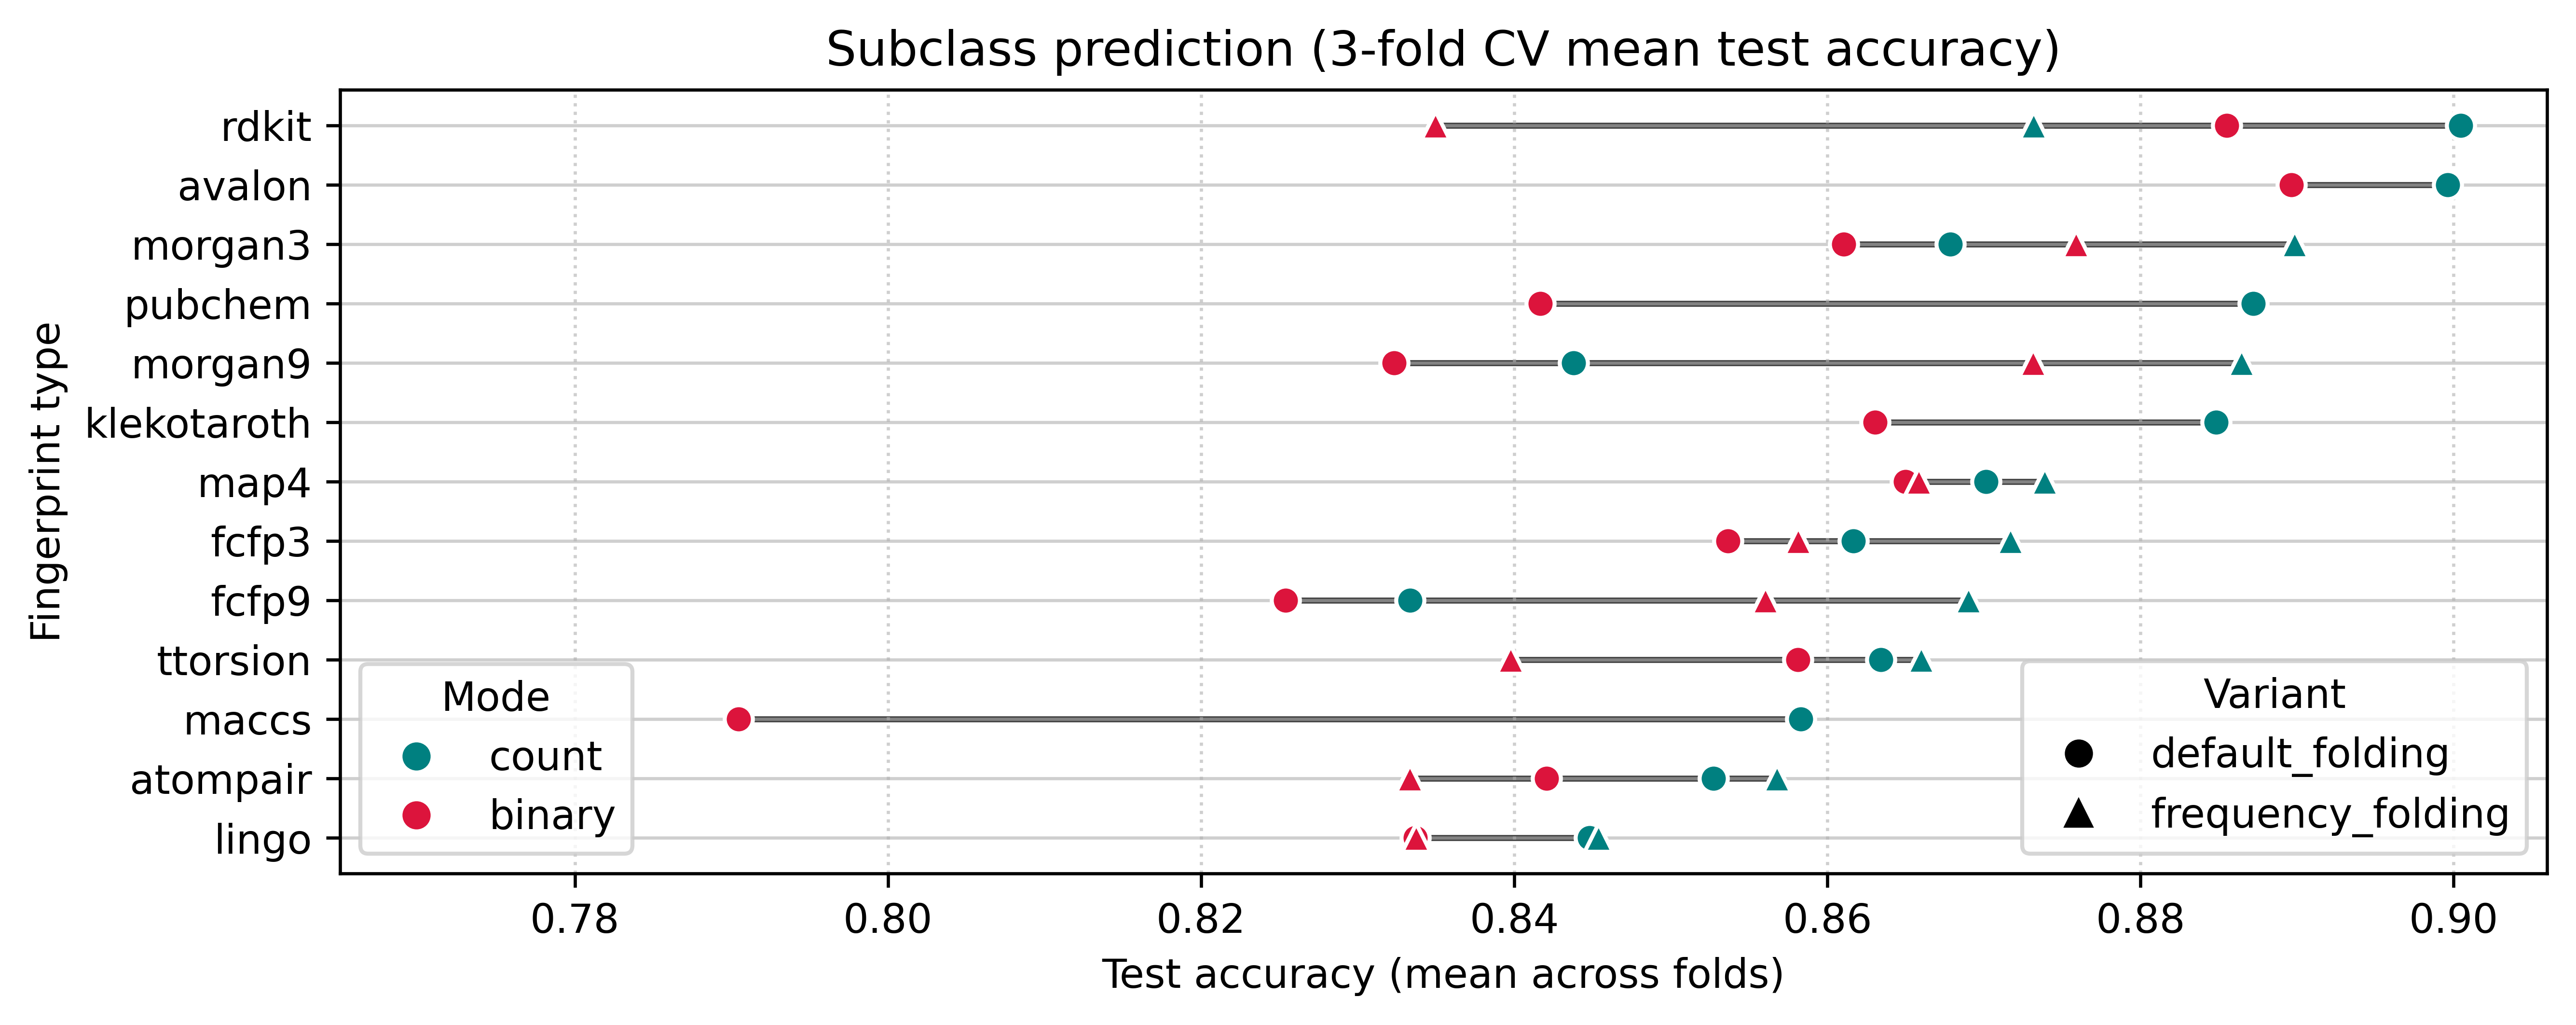

In [ ]:

# Build plotting columns
summary_df[["fingerprint_type", "mode", "marker_group", "connect_group"]] = summary_df["experiment"].apply(
    lambda x: pd.Series(split_type_and_variant(x))
)

# Use k-fold mean accuracy now
plot_df = summary_df.loc[mask, ["fingerprint_type", "accuracy_mean", "accuracy_std",
                               "mode", "marker_group", "connect_group"]].copy()

# Keep naming you like
plot_df["marker_group"] = (
    plot_df["marker_group"]
    .str.replace("collision_free", "frequency_folding", regex=False)
    .replace("base", "default_folding")
)

# Order rows by best accuracy per fingerprint type (using mean)
order = (
    plot_df.groupby("fingerprint_type")["accuracy_mean"]
    .max()
    .sort_values(ascending=True)
    .index
    .tolist()
)

SETTING_COLORS_2 = {
    "binary": "crimson",
    "count": "teal",
    "other": "gray",
}

MARKERS_2 = {
    "default_folding": "o",
    "frequency_folding": "^",
}

# Cleveland dot plot (mean accuracy)
fig, ax = cleveland_dotplot(
    row=plot_df["fingerprint_type"].tolist(),
    x=plot_df["accuracy_mean"].to_numpy(),
    color_group=plot_df["mode"].tolist(),
    marker_group=plot_df["marker_group"].tolist(),
    connect_group=plot_df["connect_group"].tolist(),
    connect=False,
    row_order=order[::-1],
    title="Subclass prediction (3-fold CV mean test accuracy)",
    xlabel="Test accuracy (mean across folds)",
    color_map=SETTING_COLORS_2,
    marker_map=MARKERS_2,
    marker_legend_title="Variant",
    color_legend_title="Mode",
)



ax.set_ylabel("Fingerprint type")
ax.invert_yaxis()
plt.xlim(0.765)
plt.tight_layout()
plt.savefig("subclass_prediction_ability_wo_biosynfoni_deeper_model.png", dpi=300)
plt.savefig("subclass_prediction_ability_wo_biosynfoni_deeper_model.pdf")
plt.show()

In [57]:
mask = ["morgan2" not in x for x in summary_df.experiment]

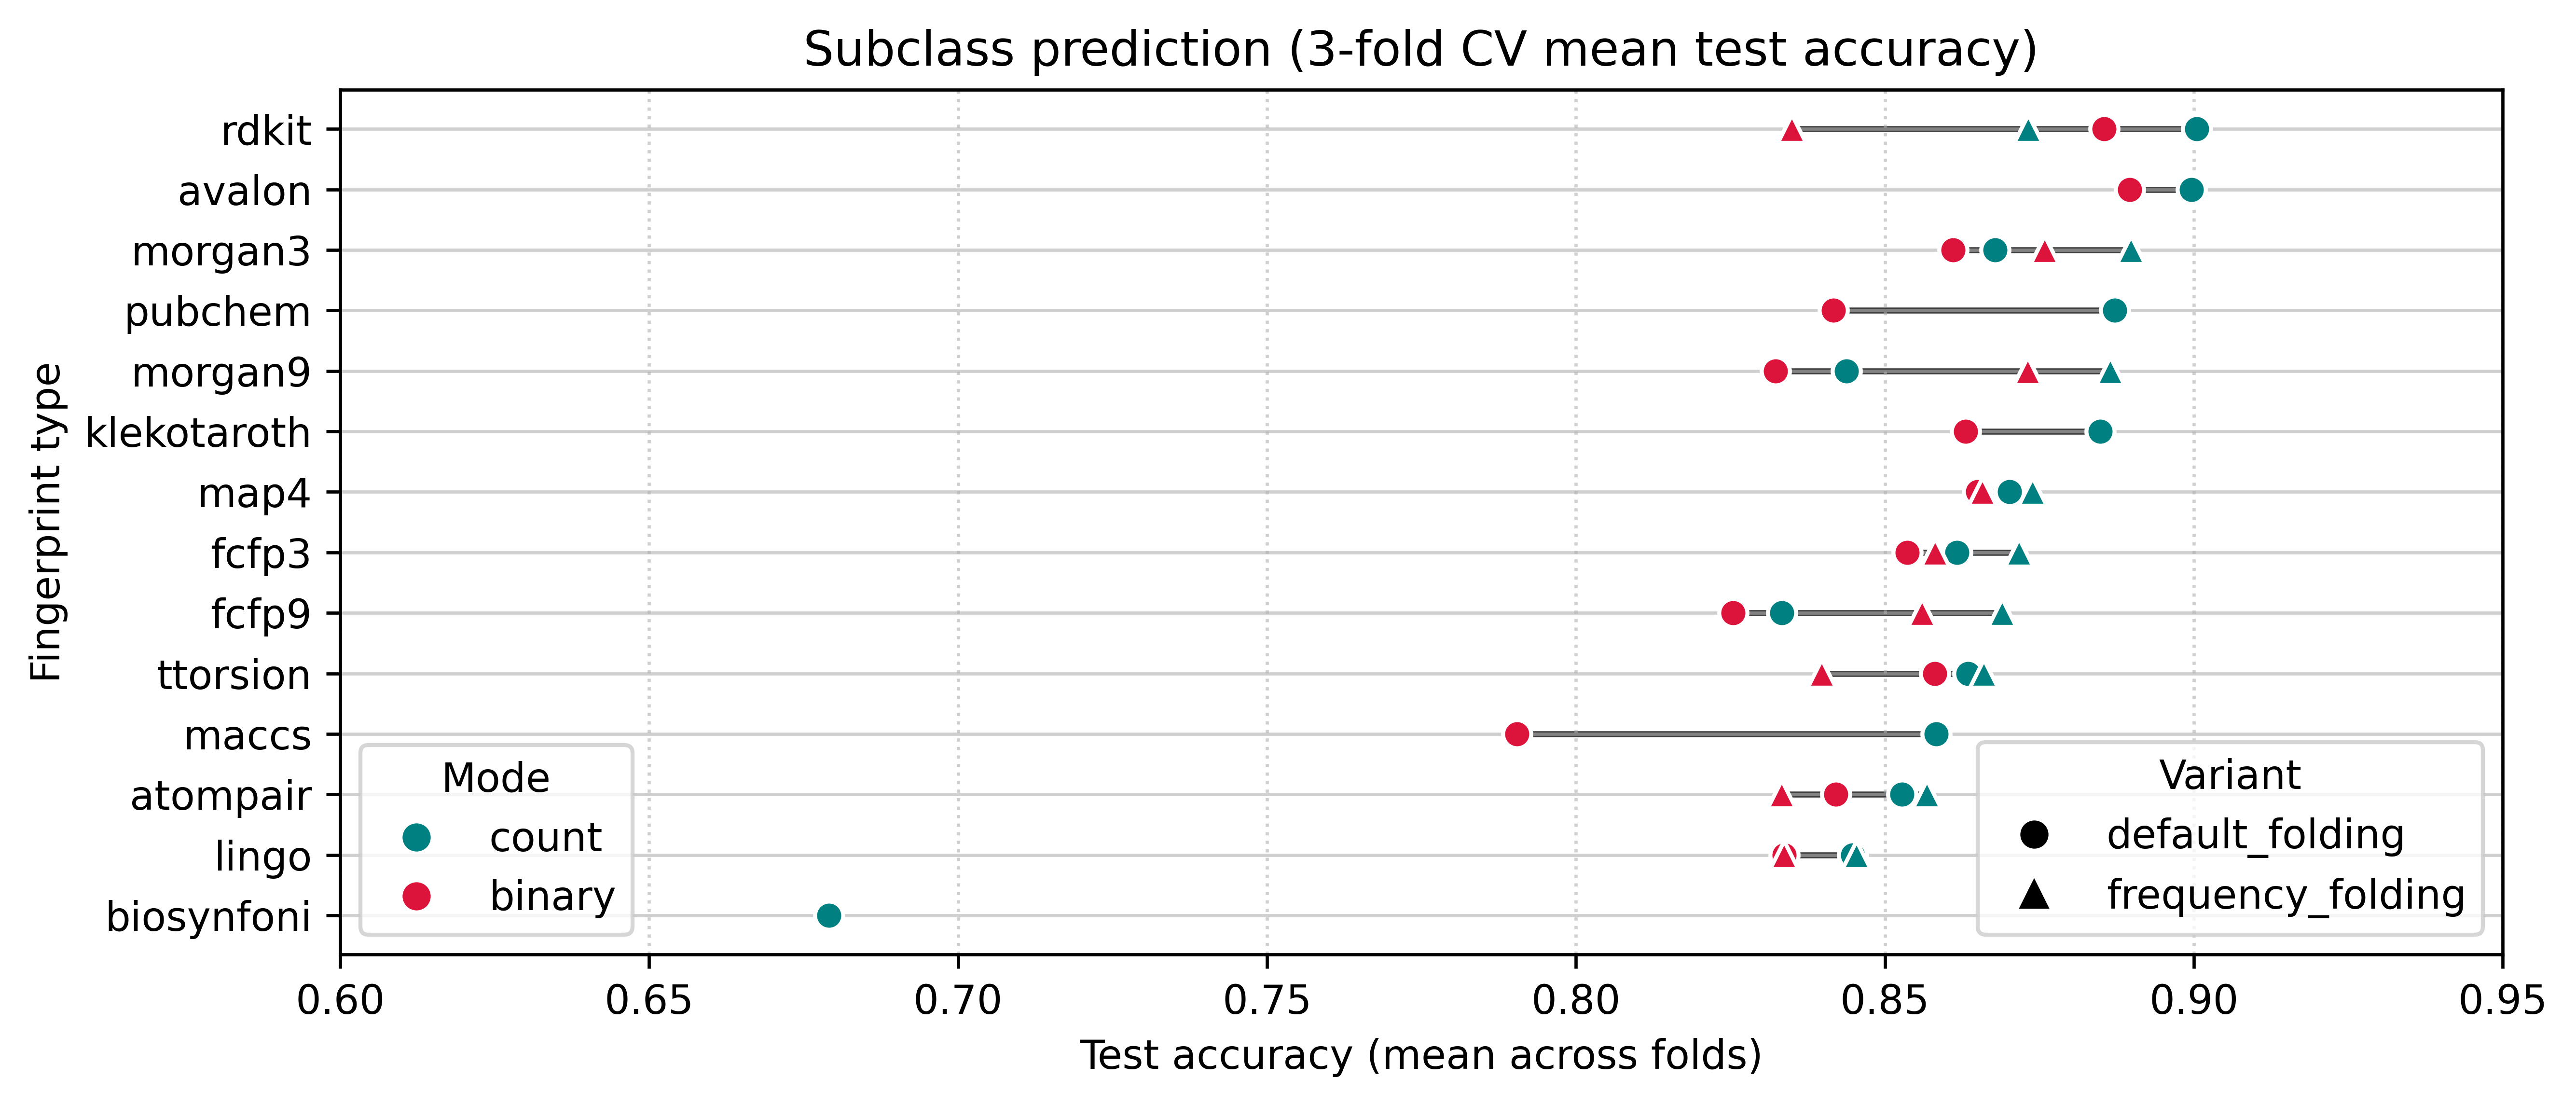

In [64]:
import matplotlib.pyplot as plt

# Optional: any filtering mask you used before
#mask = np.ones(len(summary_df), dtype=bool)  # replace with your real mask if needed

# Build tidy plotting columns (now returns 4)
summary_df[["fingerprint_type", "mode", "marker_group", "connect_group"]] = summary_df["experiment"].apply(
    lambda x: pd.Series(split_type_and_variant(x))
)

# Use k-fold mean accuracy now
plot_df = summary_df.loc[mask, ["fingerprint_type", "accuracy_mean", "accuracy_std",
                               "mode", "marker_group", "connect_group"]].copy()

# Keep naming you like
plot_df["marker_group"] = (
    plot_df["marker_group"]
    .str.replace("collision_free", "frequency_folding", regex=False)
    .replace("base", "default_folding")
)

# Order rows by best accuracy per fingerprint type (using mean)
order = (
    plot_df.groupby("fingerprint_type")["accuracy_mean"]
    .max()
    .sort_values(ascending=True)
    .index
    .tolist()
)

SETTING_COLORS_2 = {
    "binary": "crimson",
    "count": "teal",
    "other": "gray",
}

MARKERS_2 = {
    "default_folding": "o",
    "frequency_folding": "^",
}

# Cleveland dot plot (mean accuracy)
fig, ax = cleveland_dotplot(
    row=plot_df["fingerprint_type"].tolist(),
    x=plot_df["accuracy_mean"].to_numpy(),
    color_group=plot_df["mode"].tolist(),
    marker_group=plot_df["marker_group"].tolist(),
    connect_group=plot_df["connect_group"].tolist(),
    connect=False,  # set True if you want connectors
    row_order=order[::-1],
    title="Subclass prediction (3-fold CV mean test accuracy)",
    xlabel="Test accuracy (mean across folds)",
    color_map=SETTING_COLORS_2,
    marker_map=MARKERS_2,
    marker_legend_title="Variant",
    color_legend_title="Mode",
)



ax.set_ylabel("Fingerprint type")
ax.invert_yaxis()
plt.xlim(0.6, 0.95)
plt.tight_layout()
plt.savefig("subclass_prediction_ability_all_deeper_model.png", dpi=300)
plt.savefig("subclass_prediction_ability_all_deeper_model.pdf")
plt.show()